## Initialization

In [1]:
from torch.func import vjp
import torch
from torch.func import jacrev, functional_call
import torch.nn as nn
from torch import Tensor

import torch.nn.functional as F

import sys
import os

from collections import defaultdict
from typing import Callable, Dict, Any, List


current_notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '../../'))

# 将这个父目录添加到sys.path的最前面
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

print(sys.path)

['/home/hqdeng7/lijuyang/generalization', '/home/hqdeng7/.conda/envs/ljy/lib/python311.zip', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/lib-dynload', '', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/site-packages']


In [2]:
from loss_distribution.pytorch_script.visual_utils \
	import load_cifar10_data, load_model_state_dict

from ntk_result.trials.utils import *


import torchvision
import torchvision.transforms as transforms

data_pth = '/home/hqdeng7/lijuyang/generalization/loss_distribution/pytorch_script/data/cifar10'
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
train_ds = torchvision.datasets.CIFAR10(root=data_pth, train=True, download=True, transform=transform)
test_ds = torchvision.datasets.CIFAR10(root=data_pth, train=False, download=True, transform=transform)

In [3]:
model200_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_200.pth'
model200 = load_model_state_dict('cifar10', 'resnet20', 10, model200_path, 'cuda')
model100_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_100.pth'
model100 = load_model_state_dict('cifar10', 'resnet20', 10, model100_path, 'cuda')

  从字典中提取模型状态字典...
提取成功
  从字典中提取模型状态字典...
提取成功


In [4]:
def evaluate_model(model, dataloader, device='cuda'):
	model.to(device)
	model.eval()
	total_loss = 0.0
	correct = 0
	total = 0
	criterion = nn.CrossEntropyLoss()
	with torch.no_grad():
		for inputs, targets in dataloader:
			inputs, targets = inputs.to(device), targets.to(device)
			outputs = model(inputs)
			loss = criterion(outputs, targets)
			total_loss += loss.item() * inputs.size(0)
			_, predicted = outputs.max(1)
			correct += predicted.eq(targets).sum().item()
			total += targets.size(0)
	avg_loss = total_loss / total
	acc = correct / total
	return avg_loss, acc


In [5]:
from torch.optim import SGD

def train_one_batch(model, batch, optimizer):
	model.train()
	criterion = nn.CrossEntropyLoss()

	inputs, targets = batch
	inputs, targets = inputs.cuda(), targets.cuda()

	optimizer.zero_grad()
	outputs = model(inputs)
	loss = criterion(outputs, targets)
	loss.backward()
	optimizer.step()

	print(f"One training step done. Loss: {loss.item():.4f}")

In [6]:
from torch.utils.data import Subset, DataLoader

train_subdl = DataLoader(train_ds, batch_size=512)
test_dl = DataLoader(test_ds, batch_size=512)

train_loss0, train_acc0 = evaluate_model(model100, train_subdl)
test_loss0, test_acc0 = evaluate_model(model100, test_dl)

In [7]:
from torch.utils.data import Subset, DataLoader
from loss_distribution.pytorch_script.models import get_model
import random
import io
import contextlib

In [8]:
def set_seed(seed):
    """设置随机种子以确保实验可复现"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    
    # 以下两项是针对cuDNN的设置
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 设置环境变量，进一步增强确定性
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


def seed_worker(worker_id):
    """
    为每个Dataloader worker设置独立的种子。
    这对于可复现的数据增强非常重要。
    """
    worker_seed = torch.initial_seed()
    
    # 2. 为 numpy 设置种子
    np.random.seed(worker_seed + worker_id)
    
    # 3. 为 random 设置种子
    random.seed(worker_seed + worker_id)

## continueTrain

### one cluster continue

In [ ]:
test_indices = np.load('cls30_indices_arrs.npz')['arr0']

In [ ]:
train_subdl = DataLoader(train_ds, batch_size=512)
test_dl = DataLoader(test_ds, batch_size=512)

train_subds = Subset(train_ds, train_indices)
train_subdl = DataLoader(train_subds, batch_size=512)

test_subds = Subset(test_ds, test_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

train_loss0, train_acc0 = evaluate_model(model100, train_subdl)
test_loss0, test_acc0 = evaluate_model(model100, test_dl)
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)

In [ ]:
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
train_one_batch(model, next(iter(train_subdl)), optimizer)

In [ ]:
print(evaluate_model(model100, train_subdl))

In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training one cls30 cluster")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

### one cluster + random

In [ ]:
train_sub_indices_arrs = np.load('train_indices.npy')
train_sub_indices = np.reshape(train_sub_indices_arrs, (-1,))

test_sub_indices_arrs = 

train_subds = Subset(train_ds, train_sub_indices)
train_subds = Subset(train_ds, train_indices)

test_subds = Subset(test_ds, test_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

In [ ]:
orig_indices = train_subds.indices
num_random = len(orig_indices) * 10
random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])

bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training one cls30 + random")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

### cls10 one cluster + random

In [ ]:
test_indices = np.load('cls10_indices_arrs.npz', allow_pickle=True)['arr_0']
train_indices = np.load('cls10_train_indices_arrs.npy')[0]

In [ ]:
train_subds = Subset(train_ds, train_indices)

test_subds = Subset(test_ds, test_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

In [ ]:
orig_indices = train_subds.indices
num_random = len(orig_indices) * 10
random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])

bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After trainig one cls10 cluster + random samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

### all clusters continue

#### preparation

In [ ]:
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)
train_subdl = DataLoader(train_subds, batch_size=512)

test_sub_indices = np.concatenate(filtered_cls30_indices_arrs)
test_subds = Subset(test_ds, test_sub_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

In [ ]:
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

In [ ]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed) 
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### in order

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
for train_indices in train_indices_arrs:
	train_subds = Subset(train_ds, train_indices)
	train_subdl = DataLoader(train_subds, batch_size=512)
	train_one_batch(model, next(iter(train_subdl)), optimizer)


In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training clusters in order")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
import torch
torch.cuda.empty_cache()

#### shuffle

In [ ]:
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)
train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True)

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
for batch in train_subdl:
	train_one_batch(model, batch, optimizer)


In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training clusters with shuffle")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

#### all clusters + random

In [ ]:
orig_indices = train_subds.indices
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)
train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True)

num_random = len(orig_indices) * 4

random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])
bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

In [ ]:
num_random + len(orig_indices)

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for batch in bigger_train_subdl:
	with contextlib.redirect_stdout(io.StringIO()):
		train_one_batch(model, batch, optimizer)

In [ ]:
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

In [ ]:
print("After training shuffled cls30 + random samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
test_sub_loss0, test_sub_acc0 = evaluate_model(model100, test_subdl)
print("Original loss/acc")
print(f"train loss: {train_loss0:.4f}, train acc: {train_acc0:.4f}")
print(f"test loss: {test_loss0:.4f}, test acc: {test_acc0:.4f}")
print(f"sub test loss: {test_sub_loss0:.4f}, sub test acc: {test_sub_acc0:.4f}")

#### cls15 + random

In [ ]:
test_indices = np.load('cls10_indices_arrs.npz', allow_pickle=True)['arr_0']
train_indices_arrs = np.load('cls10_train_indices_arrs.npy')
train_indices = np.reshape(train_indices_arrs, (-1,))

train_subds = Subset(train_ds, train_indices)
train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True)

orig_indices = train_subds.indices
num_random = len(orig_indices) * 6
random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])
bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

for batch in bigger_train_subdl:
	train_one_batch(model, batch, optimizer)

train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training shuffled cls15 + random samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

## contrast

### one epoch

In [ ]:
seed_value = 42
set_seed(seed_value)

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

test_sub_indices = np.concatenate(filtered_cls30_indices_arrs)
test_subds = Subset(test_ds, test_sub_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

lr = 0.05
optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for batch in train_subdl:
	with contextlib.redirect_stdout(io.StringIO()):
		train_one_batch(model, batch, optimizer)

train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training one epoch")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

#### 5 epochs

In [ ]:
import io
import contextlib

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

for i in range(5):
	for batch in train_subdl:
		with contextlib.redirect_stdout(io.StringIO()):
			train_one_batch(model, batch, optimizer)

train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training one epoch")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

In [ ]:
test_indices = np.load('cls10_indices_arrs.npz', allow_pickle=True)['arr_0']
train_indices_arrs = np.load('cls30_train_indices_arrs.npy')
train_indices = np.reshape(train_indices_arrs, (-1,))

train_subds = Subset(train_ds, train_indices)
train_subdl = DataLoader(train_subds, batch_size=512, shuffle=True)

orig_indices = train_subds.indices
num_random = len(orig_indices) * 6
random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=False)

combined_indices = np.concatenate([orig_indices, random_indices])
bigger_train_subds = Subset(train_ds, combined_indices)
bigger_train_subdl = DataLoader(bigger_train_subds, batch_size=512, shuffle=True)

model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
for i in range(5):
	for batch in bigger_train_subdl:
		with contextlib.redirect_stdout(io.StringIO()):
			train_one_batch(model, batch, optimizer)

train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training shuffled cls15 + random samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")
print(f"sub test loss: {test_sub_loss1:.4f}, sub test acc: {test_sub_acc1:.4f}")

### naive hard example mining

In [ ]:
from torch.utils.data import Subset, DataLoader

# Find top 1000 high-loss samples from the training set
topk = 1000
batch_loss_fn = get_batch_loss_fn(model100)
high_loss_indices = list(zip(*find_topk_samples(train_ds, batch_loss_fn, k=topk)))[1]

# Create DataLoader for high-loss samples
high_loss_subds = Subset(train_ds, high_loss_indices)
high_loss_subdl = DataLoader(high_loss_subds, batch_size=512, shuffle=True)

In [ ]:
# Re-initialize new_model from model100
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
for batch in high_loss_subdl:
	train_one_batch(model, batch, optimizer)

# Evaluate and print results
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After training on high-loss samples")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")

In [ ]:
len(high_loss_subdl)

### online hard example mining

In [ ]:
import torch.nn.functional as F

def train_one_epoch_ohem(model, dataloader, optimizer, device, top_k_ratio=0.5):
    """
    Args:
        model: nn.Module
        dataloader: DataLoader
        optimizer: torch.optim
        device: 'cuda' or 'cpu'
        top_k_ratio: 选取 batch 内 top-k 样本的比例 (0~1)
    """
    model.train()
    criterion = nn.CrossEntropyLoss(reduction='none')  # 不要平均，返回每个样本的 loss

    total_loss, total_correct, total_seen = 0, 0, 0

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        # 逐样本 loss
        losses = criterion(outputs, targets)  # shape: (batch_size,)
        
        # 选取 batch 内 top-k
        batch_size = losses.shape[0]
        k = max(1, int(batch_size * top_k_ratio))  # 至少要有1个
        topk_loss, topk_idx = torch.topk(losses, k)

        # 只对 hardest k 个样本反传
        topk_loss.mean().backward()
        optimizer.step()

        # 统计
        preds = outputs.argmax(dim=1)
        total_correct += (preds == targets).sum().item()
        total_seen += batch_size
        total_loss += topk_loss.sum().item()  # 累加 hard 样本 loss

    avg_loss = total_loss / total_seen
    avg_acc = total_correct / total_seen
    return avg_loss, avg_acc

In [ ]:
model = get_model('cifar10', 'resnet20', weights=None, num_classes=10)
model.load_state_dict(model100.state_dict())
model.to('cuda')

lr = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
train_one_epoch_ohem(model, train_subdl, optimizer, "cuda", top_k_ratio=1)

# Evaluate and print results
train_loss1, train_acc1 = evaluate_model(model, train_subdl)
test_loss1, test_acc1 = evaluate_model(model, test_dl)
test_sub_loss1, test_sub_acc1 = evaluate_model(model, test_subdl)

print("After online hard example mining")
print(f"lr: {lr}")
print(f"train loss: {train_loss1:.4f}, train acc: {train_acc1:.4f}")
print(f"test loss: {test_loss1:.4f}, test acc: {test_acc1:.4f}")

## not to train

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.func import functional_call, vmap, grad  # grad 在较新 torch.func 中可用
from torch.utils.data import DataLoader
import heapq
from functorch import make_functional_with_buffers

from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans

def cluster_and_get_centroids(data, n_clusters: int):
	kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
	kmeans.fit(data)

	return kmeans.labels_, kmeans.cluster_centers_


def find_closest_samples(samples, center):
	# 计算该聚类中所有样本到其中心点的距离
	distances = cdist(samples, [center], 'euclidean').flatten()
	
	# 找到最小距离及其对应的样本索引
	min_dist_idx = np.argmin(distances)
	
	return min_dist_idx

X_pca = np.load('X_pca.npy')
cls30_labels, cls30_centers = cluster_and_get_centroids(X_pca, 30)


def get_param_jac(model, inputs, device="cuda"):

	model.eval()
	inputs = inputs.to(device)
	params = dict(model.named_parameters())
	buffers = dict(model.named_buffers())

	def grad_fn(params, input, class_idx):
		def loss_fn(params):
			out = functional_call(model, (params, buffers), input.unsqueeze(0))  # (1, C)
			oh = torch.zeros_like(out)  # (1, C)
			oh = oh.scatter(1, class_idx.view(1,1), 1.0)  # out-of-place, safe for vmap
			return (out[0] * oh).sum()  # 标量
		grads = grad(loss_fn)(params)
		return grads  # tuple of param-shaped grads
	
	class_idxs = torch.arange(10, device=device)

	def per_sample_jac(input):
		grads_per_class = vmap(lambda c: grad_fn(params, input, c))(class_idxs)
		# grads_per_class: tuple of tensors, each (C, *param_shape)
		flat = []
		for g in grads_per_class.values():  # over params
			flat.append(g.reshape(g.shape[0], -1))  # (C, param_dim)
		return torch.cat(flat, dim=1)  # (C, P)

	# vmap over batch
	jacobian = vmap(per_sample_jac)(inputs)  # (B, C, P)
	return jacobian


# ---------- get_batch_myentk_fn：名称、接口与原来一致，但内部使用更快的 get_param_jac（按块） ----------
def get_batch_myentk_fn(model, 
						ref_input,
						ref_label,
						loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)

	ref_input = ref_input.unsqueeze(0)
	ref_input = ref_input.to(device)

	# 用我们优化后的 get_param_jac（它内部会把 model functionalize 并缓存）
	ref_jacob = get_param_jac(model, ref_input, device=device)  # (1, out_dim, P)

	# 构造左向量（与原实现一致）
	t = torch.full((ref_jacob.shape[1],), -1, device=device)
	t[ref_label] = 1
	left_mat = ref_jacob * t.view(1, -1, 1)  # (1, out_dim, P)
	left_mat = torch.sum(left_mat.squeeze(0), 0)  # (P,)

	def batch_myentk_fn(batch):
		inputs, labels = batch
		inputs = inputs.to(device)
		labels = labels.to(device)

		# 计算 batch 的 jacob（按块）
		jacobs = get_param_jac(model, inputs, device=device)  # (B, out_dim, P)
		right_mat = jacobs[torch.arange(len(inputs)), labels]  # (B, P)

		results = right_mat.mv(left_mat)  # (B,)
		return results  # 保持 tensor 返回（跟你原来代码的返回类型一致）
	
	return batch_myentk_fn

# ---------- find_topk_samples：名字与原来一致，但内部用向量化 topk 合并以加速 ----------
def find_topk_samples(
	ds, 
	fn,
	k=16,
	batch_size=256,
	reverse=False,
	show_progress=True,
	num_workers=4,
	pin_memory=True
):
	"""
	返回 list of (value, idx) 与原来接口相同。
	优化：使用 torch.topk 在 CPU/Tensor 上流式合并 top-k，避免 Python 层 per-sample heap 操作。
	"""
	dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
	best_vals = None  # tensor
	best_idxs = None
	idx_offset = 0

	iterator = dl
	if show_progress:
		iterator = tqdm(dl)

	for batch in iterator:
		batch_res = fn(batch)  # 假设返回一维 tensor (B,) 在 device 上或 CPU 上
		if isinstance(batch_res, torch.Tensor):
			vals = batch_res.detach().cpu()
		else:
			vals = torch.tensor(batch_res)  # 兜底

		B = vals.shape[0]
		idxs = torch.arange(idx_offset, idx_offset + B, dtype=torch.long)

		# apply reverse semantics: if reverse True, we want smallest k, so invert by negating
		vals_for_sort = -vals if reverse else vals

		if best_vals is None:
			if vals_for_sort.shape[0] <= k:
				best_vals = vals_for_sort.clone()
				best_idxs = idxs.clone()
			else:
				topv, topi = torch.topk(vals_for_sort, k)
				best_vals = topv.clone()
				best_idxs = idxs[topi].clone()
		else:
			# merge existing best and this batch, keep top k
			cat_vals = torch.cat([best_vals, vals_for_sort])
			cat_idxs = torch.cat([best_idxs, idxs])
			if cat_vals.shape[0] <= k:
				best_vals = cat_vals
				best_idxs = cat_idxs
			else:
				topv, topi = torch.topk(cat_vals, k)
				best_vals = topv
				best_idxs = cat_idxs[topi]

		idx_offset += B

	if best_vals is None:
		return []

	final_vals = -best_vals if reverse else best_vals
	sorted_vals, order = torch.sort(final_vals, descending=True)
	sorted_idxs = best_idxs[order]

	return [(float(v.item()), int(i.item())) for v, i in zip(sorted_vals, sorted_idxs)]

In [ ]:
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

num_poison = 20
not_train_indices = np.array([], dtype=int)
for test_indices in filtered_cls30_indices_arrs:
	tar_idx = test_indices[find_closest_samples(X_pca[cls30_labels == i], cls30_centers[i])]
	ref_input, ref_label = test_ds[tar_idx]
	fn = get_batch_myentk_fn(model100, ref_input, ref_label)
	topk = find_topk_samples(train_ds, fn, k=num_poison, batch_size=256, reverse=True)
	new_not_train_indices = list(zip(*topk))[1]
	print(new_not_train_indices)
	not_train_indices = np.union1d(not_train_indices, new_not_train_indices)

## statistics

#### std

In [17]:

def analyze_func_runs(
	target_func: Callable[[], Dict[str, float]], 
	repeat_num: int = 10,
	precision: int = 4
) -> None:
	
	results_collection = defaultdict(list)

	for i in tqdm(range(repeat_num)):
		output_dict = target_func(i)
		
		for key, value in output_dict.items():
			results_collection[key].append(value)
	
	for key, values in results_collection.items():
		mean = np.mean(values)
		std = np.std(values)
		output_str = f"{mean:.{precision}f} ± {std:.{precision}f}"
		
		print(f"{key.ljust(20)}: {output_str}")

In [18]:
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

test_sub_indices = np.concatenate(filtered_cls30_indices_arrs)
test_subds = Subset(test_ds, test_sub_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

def copy_model(original_model, ds_name='cifar10', model_name='resnet20'):
	model = get_model(ds_name, model_name, weights=None, num_classes=10)
	model.load_state_dict(original_model.state_dict())
	model.to('cuda')

	return model

def make_cont_train_fn(
		original_model, 
		train_sub_ds, 
		lr=0.05,
		epoch_num=1):

	def cont_train_fn(seed):
		set_seed(seed)
		train_sub_dl = DataLoader(train_sub_ds, batch_size=512, num_workers=0, shuffle=True)

		model = copy_model(original_model)

		optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
		for _ in range(epoch_num):
			for batch in train_sub_dl:
				with contextlib.redirect_stdout(io.StringIO()):
					train_one_batch(model, batch, optimizer)

		result = {}
		result['train_loss'], result['train_acc'] = evaluate_model(model, train_subdl)
		result['test_loss'], result['test_acc'] = evaluate_model(model, test_dl)
		result['test_sub_loss'], result['test_sub_acc'] = evaluate_model(model, test_subdl)

		return result
		

	return cont_train_fn

In [ ]:
new_model = copy_model(model100)
cont_train_one_epoch_fn = make_cont_train_fn(new_model, train_ds, lr=0.01, epoch_num=2)
print("after training one epoch")
analyze_func_runs(cont_train_one_epoch_fn)

In [ ]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

def make_cont_train_cls30_rand_fn(seed=42, lr=0.05,
								  sample_num=len(train_ds), 
								  target_sample_num=len(train_ds)):
	
	set_seed(seed)

	orig_indices = train_subds.indices
	num_random = sample_num - len(orig_indices)

	random_indices = np.random.choice(np.array(range(len(train_ds))), size=num_random, replace=True)

	combined_indices = np.concatenate([orig_indices, random_indices])
	bigger_train_subds = Subset(train_ds, combined_indices)

	return make_cont_train_fn(bigger_train_subds, lr=lr, epoch_num=target_sample_num//sample_num)

In [ ]:
print("after training cls30+random")
cont_train_cls30_rand_fn = \
	make_cont_train_cls30_rand_fn(lr=0.01, sample_num=len(train_subds)*8, 
							   target_sample_num=len(train_ds)*2)
analyze_func_runs(cont_train_cls30_rand_fn, repeat_num=1)

In [ ]:
# data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
# filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

# num_poison = 20
# not_train_indices = np.array([], dtype=int)
# for i, test_indices in enumerate(filtered_cls30_indices_arrs):
# 	tar_idx = test_indices[find_closest_samples(X_pca[cls30_labels == i], cls30_centers[i])]
# 	ref_input, ref_label = test_ds[tar_idx]
# 	fn = get_batch_myentk_fn(model100, ref_input, ref_label)
# 	topk = find_topk_samples(train_ds, fn, k=num_poison, batch_size=256, reverse=True)
# 	new_not_train_indices = list(zip(*topk))[1]
# 	print(new_not_train_indices)
# 	not_train_indices = np.union1d(not_train_indices, new_not_train_indices)
# 	print(len(not_train_indices))

# np.save("not_to_train_indices.npy", not_train_indices)

In [20]:
not_train_indices = np.load("not_to_train_indices.npy")

bad_indices = set(not_train_indices)  # 转成集合加速查询
all_indices = [i for i in range(len(train_ds)) if i not in bad_indices]

filtered_ds = Subset(train_ds, all_indices)
not_to_train_fn = make_cont_train_fn(model100, filtered_ds, lr=0.05, epoch_num=1)

print("after not to train")
analyze_func_runs(not_to_train_fn)

after not to train


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [05:20<00:00, 32.07s/it]

train_loss          : 0.1212 ± 0.0043
train_acc           : 0.9627 ± 0.0022
test_loss           : 0.2674 ± 0.0061
test_acc            : 0.9075 ± 0.0016
test_sub_loss       : 2.5917 ± 0.0514
test_sub_acc        : 0.1464 ± 0.0185


In [ ]:
len(not_train_indices)

In [ ]:
len(filtered_cls30_indices_arrs)

In [ ]:
cont_train_five_epoch_fn = make_cont_train_fn(train_ds, lr=0.03, epoch_num=5)
print("after training five epoch")
analyze_func_runs(cont_train_five_epoch_fn)

In [ ]:
train_indices_arrs

### plot

#### plot distribution

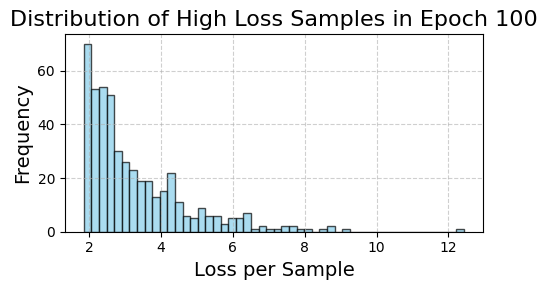

📊 Loss 分布统计:
   样本总数: 474
   平均 Loss: 3.2753
   中位数 Loss: 2.7380
   最小 Loss: 1.8506
   最大 Loss: 12.4328
   标准差: 1.4456


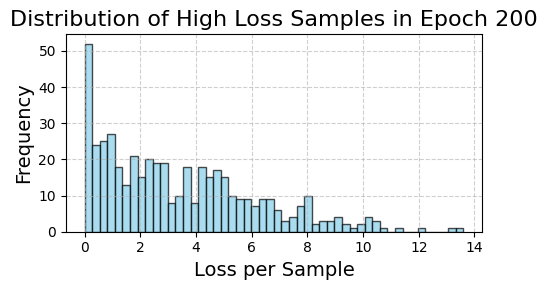

📊 Loss 分布统计:
   样本总数: 474
   平均 Loss: 3.3835
   中位数 Loss: 2.7634
   最小 Loss: 0.0001
   最大 Loss: 13.5940
   标准差: 2.7699


In [15]:
data = np.load("filtered_cls30_indices_arrs.npz", allow_pickle=True)
filtered_cls30_indices_arrs = [data[f"arr_{i}"] for i in range(len(data.files))]

test_sub_indices = np.concatenate(filtered_cls30_indices_arrs)
test_subds = Subset(test_ds, test_sub_indices)
test_subdl = DataLoader(test_subds, batch_size=512)

def plot_loss_distribution(
    model: torch.nn.Module,
    ds,
    batch_size: int = 512,
    title: str = "Loss Distribution",
    bins: int = 50,
    figsize: tuple = (5, 3),
    device = 'cuda'
):
    """
    绘制模型在给定数据集上每个样本的损失值分布直方图。
    """
    model.eval()  # 确保模型处于评估模式

    # 创建 DataLoader
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    all_losses = []

    # 使用无 reduction 的损失函数（逐样本计算）
    criterion = torch.nn.CrossEntropyLoss(reduction='none')  # 假设是分类任务

    with torch.no_grad():
        for batch in dl:
            # 假设 batch 是 (inputs, labels) 格式
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            losses = criterion(outputs, labels)  # shape: [batch_size]
            all_losses.extend(losses.cpu().numpy())

    # 转换为 numpy 数组便于绘图
    import numpy as np
    all_losses = np.array(all_losses)

    # 绘图
    plt.figure(figsize=figsize)
    plt.hist(all_losses, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(title, fontsize=16)
    plt.xlabel('Loss per Sample', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 可选：打印统计信息
    print(f"📊 Loss 分布统计:")
    print(f"   样本总数: {len(all_losses)}")
    print(f"   平均 Loss: {all_losses.mean():.4f}")
    print(f"   中位数 Loss: {np.median(all_losses):.4f}")
    print(f"   最小 Loss: {all_losses.min():.4f}")
    print(f"   最大 Loss: {all_losses.max():.4f}")
    print(f"   标准差: {all_losses.std():.4f}")
	
plot_loss_distribution(model100, test_subds, title='Distribution of High Loss Samples in Epoch 100')
model200.to('cuda')
plot_loss_distribution(model200, test_subds, title='Distribution of High Loss Samples in Epoch 200')

#### plot normal training

In [11]:
def make_cont_train_curve_fn(
	model,
	train_sub_ds,
	lr=0.05,
	total_samples=5*len(train_ds),    # 总训练样本数
	eval_interval=0.5*len(train_ds),    # 每多少样本评估一次
	include_init=True       # 是否包含初始状态（0 样本时）
):
	"""
	在固定总样本数下训练，分阶段评估，用于公平比较不同子集。
	返回 fn(seed) -> { 'train_loss': [...], 'test_loss': [...], 'test_sub_loss': [...] }
	"""
	def train_fn(seed):
		set_seed(seed)
		local_model = copy_model(model)
		optimizer = SGD(local_model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
		
		# 准备数据迭代器
		train_subdl = DataLoader(train_sub_ds, batch_size=512, shuffle=True, num_workers=0)
		data_iter = iter(train_subdl)
		
		results = {k: [] for k in ['train_loss', 'test_loss', 'test_sub_loss']}
		
		# 初始评估
		train_dl = DataLoader(train_ds, batch_size=512, shuffle=True, num_workers=0)
		if include_init:
			for key, dl in zip(results.keys(), [train_dl, test_dl, test_subdl]):
				loss, _ = evaluate_model(local_model, dl)
				results[key].append(loss)
		
		# 分阶段训练
		samples_done = 0
		print(samples_done)
		
		while samples_done < total_samples:
			stage_target = min(eval_interval, total_samples - samples_done)
			stage_done = 0
			
			while stage_done < stage_target:
				try:
					batch = next(data_iter)
				except StopIteration:
					data_iter = iter(train_subdl)
					batch = next(data_iter)
				
				bs = batch[0].size(0) if isinstance(batch, (list, tuple)) else batch.size(0)
				
				with contextlib.redirect_stdout(io.StringIO()):
					train_one_batch(local_model, batch, optimizer)
				
				stage_done += bs
				samples_done += bs
			
			# 本阶段结束，评估
			for key, dl in zip(results.keys(), [train_subdl, test_dl, test_subdl]):
				loss, _ = evaluate_model(local_model, dl)
				results[key].append(loss)
			
			print(samples_done, results)
		
		return results
	
	return train_fn


def analyze_multi_stage_runs(
    target_func: Callable[[int], Dict[str, List[float]]],
    repeat_num: int = 10,
    max_stages: int = None  # 可选：限制最多分析多少阶段，None = 无限制
) -> Dict[str, np.ndarray]:
    """
    运行 target_func 多次（每次传入不同 seed），
    收集每个阶段（stage）的 loss，计算平均值，
    返回 dict of ndarray，shape=(num_stages,)
    """
    # 第一次运行，获取结构和阶段数
    sample_output = target_func(0)
    keys = list(sample_output.keys())
    num_stages_actual = len(sample_output[keys[0]])  # 假设所有 key 长度一致

    # 如果设置了 max_stages，取较小值
    if max_stages is not None:
        num_stages = min(max_stages, num_stages_actual)
    else:
        num_stages = num_stages_actual

    # 初始化收集器：每个 key 对应一个二维列表 [stage][repeat]
    stage_results = defaultdict(lambda: [[] for _ in range(num_stages)])
    
    # 第一次的结果也要加入统计（上面只用了它来探测结构）
    for key, stage_values in sample_output.items():
        for stage_idx, value in enumerate(stage_values[:num_stages]):  # 截断到 num_stages
            stage_results[key][stage_idx].append(value)

    # 剩余 repeat_num - 1 次运行
    for i in tqdm(range(1, repeat_num), desc="Running repeats"):
        output_dict = target_func(i)
        for key, stage_values in output_dict.items():
            for stage_idx, value in enumerate(stage_values[:num_stages]):  # 同样截断
                stage_results[key][stage_idx].append(value)
    
    # 转换为 ndarray 平均值
    final_results = {}
    for key, stage_lists in stage_results.items():
        averages = [np.mean(values) for values in stage_lists]
        final_results[key] = np.array(averages)
    
    return final_results

In [ ]:
# 1. 构造多 epoch 训练函数
multi_train_fn = make_cont_train_curve_fn(
	model=model100,
	train_sub_ds=train_ds,
	lr=0.05,
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=multi_train_fn,
	repeat_num=10
)

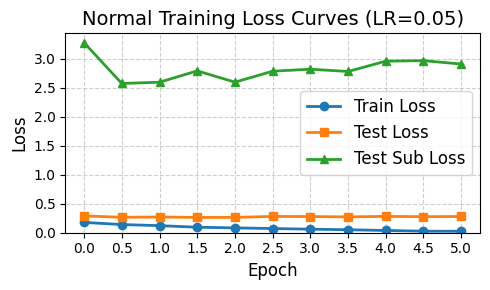

{'train_loss': [0.17784367995262146, 0.1410971928834915, 0.1218765637588501, 0.09477578934669495, 0.08332547618627548, 0.07210285425186157, 0.06092038222193718, 0.051256503247022626, 0.038661433967351916, 0.02661241720318794, 0.02485323562383652], 'test_loss': [0.29008910851478575, 0.26578320298194885, 0.2714660212993622, 0.26352498648166656, 0.2645266917705536, 0.2810440327644348, 0.278873992061615, 0.2729335593223572, 0.2818593379020691, 0.2763371033191681, 0.2800218494415283], 'test_sub_loss': [3.275315284729004, 2.5728888511657715, 2.595473051071167, 2.7902114391326904, 2.5961546897888184, 2.7848315238952637, 2.8197150230407715, 2.77978777885437, 2.958085298538208, 2.966841459274292, 2.90836238861084]}


In [10]:
def plot_training_losses(results_dict: dict, 
						 title: str = "Training Losses over Epochs",
						 figsize: tuple = (5, 3),
                         epoch_interval=0.5
                         ):
    """
    绘制 train_loss, test_loss, test_sub_loss 随 epoch 变化的曲线
    
    参数:
        results_dict: dict with keys 'train_loss', 'test_loss', 'test_sub_loss'
                     each value is np.ndarray of shape (6,) for epochs 0~5
        title: 图标题（可选）
    """
    epochs = [i * epoch_interval for i in np.arange(0, len(results_dict['train_loss']))]

    plt.figure(figsize=figsize)
    plt.plot(epochs, results_dict['train_loss'], 
             marker='o', label='Train Loss', linewidth=2, markersize=6)
    plt.plot(epochs, results_dict['test_loss'], 
             marker='s', label='Test Loss', linewidth=2, markersize=6)
    plt.plot(epochs, results_dict['test_sub_loss'], 
             marker='^', label='Test Sub Loss', linewidth=2, markersize=6)

    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(bottom=0)  # 纵坐标从 0 开始
    plt.xticks(epochs)  # 显示所有 epoch 刻度
    plt.tight_layout()
    plt.show()

results_dict = {'train_loss': [0.17784367995262146, 0.1410971928834915, 0.1218765637588501, 0.09477578934669495, 0.08332547618627548, 0.07210285425186157, 0.06092038222193718, 0.051256503247022626, 0.038661433967351916, 0.02661241720318794, 0.02485323562383652], 
 'test_loss': [0.29008910851478575, 0.26578320298194885, 0.2714660212993622, 0.26352498648166656, 0.2645266917705536, 0.2810440327644348, 0.278873992061615, 0.2729335593223572, 0.2818593379020691, 0.2763371033191681, 0.2800218494415283], 
 'test_sub_loss': [3.275315284729004, 2.5728888511657715, 2.595473051071167, 2.7902114391326904, 2.5961546897888184, 2.7848315238952637, 2.8197150230407715, 2.77978777885437, 2.958085298538208, 2.966841459274292, 2.90836238861084]}
plot_training_losses(results_dict, title="Normal Training Loss Curves (LR=0.05)")
print(results_dict)

In [28]:
# 1. 构造多 epoch 训练函数
multi_train_fn = make_cont_train_curve_fn(
	model=model100,
	train_sub_ds=train_ds,
	lr=0.01,
)

# 2. 分析多次运行
results_dict = analyze_multi_stage_runs(
	target_func=multi_train_fn,
	repeat_num=10
)

0
25088 {'train_loss': [0.17784368547439575, 0.14626874442100524], 'test_loss': [0.29008910851478575, 0.2610541339874268], 'test_sub_loss': [3.275315284729004, 2.744579315185547]}
50512 {'train_loss': [0.17784368547439575, 0.14626874442100524, 0.13291334139823913], 'test_loss': [0.29008910851478575, 0.2610541339874268, 0.25101681094169614], 'test_sub_loss': [3.275315284729004, 2.744579315185547, 2.669768810272217]}
75600 {'train_loss': [0.17784368547439575, 0.14626874442100524, 0.13291334139823913, 0.12427565501213074], 'test_loss': [0.29008910851478575, 0.2610541339874268, 0.25101681094169614, 0.2483482033252716], 'test_sub_loss': [3.275315284729004, 2.744579315185547, 2.669768810272217, 2.6424334049224854]}
101024 {'train_loss': [0.17784368547439575, 0.14626874442100524, 0.13291334139823913, 0.12427565501213074, 0.11630465394496918], 'test_loss': [0.29008910851478575, 0.2610541339874268, 0.25101681094169614, 0.2483482033252716, 0.24650992527008056], 'test_sub_loss': [3.27531528472900

Running repeats:   0%|          | 0/9 [00:00<?, ?it/s]

0
25088 {'train_loss': [0.17784368330478667, 0.1456287676477432], 'test_loss': [0.29008910851478575, 0.2592176818847656], 'test_sub_loss': [3.275315284729004, 2.76218581199646]}
50512 {'train_loss': [0.17784368330478667, 0.1456287676477432, 0.13337358735084534], 'test_loss': [0.29008910851478575, 0.2592176818847656, 0.2523656000137329], 'test_sub_loss': [3.275315284729004, 2.76218581199646, 2.6423027515411377]}
75600 {'train_loss': [0.17784368330478667, 0.1456287676477432, 0.13337358735084534, 0.12474716540336608], 'test_loss': [0.29008910851478575, 0.2592176818847656, 0.2523656000137329, 0.2497008432149887], 'test_sub_loss': [3.275315284729004, 2.76218581199646, 2.6423027515411377, 2.6895339488983154]}
101024 {'train_loss': [0.17784368330478667, 0.1456287676477432, 0.13337358735084534, 0.12474716540336608, 0.116100904276371], 'test_loss': [0.29008910851478575, 0.2592176818847656, 0.2523656000137329, 0.2497008432149887, 0.2476575065612793], 'test_sub_loss': [3.275315284729004, 2.762185

Running repeats:  11%|█         | 1/9 [04:30<36:00, 270.03s/it]

250000 {'train_loss': [0.17784368330478667, 0.1456287676477432, 0.13337358735084534, 0.12474716540336608, 0.116100904276371, 0.10999078217744827, 0.10173790025234222, 0.09694343065261841, 0.09066607929706573, 0.08633472542762756, 0.08217885858774185], 'test_loss': [0.29008910851478575, 0.2592176818847656, 0.2523656000137329, 0.2497008432149887, 0.2476575065612793, 0.2472487632036209, 0.24352146766185762, 0.24482468264102936, 0.24353058393001556, 0.24369993057250977, 0.24513890318870543], 'test_sub_loss': [3.275315284729004, 2.76218581199646, 2.6423027515411377, 2.6895339488983154, 2.692622423171997, 2.6769869327545166, 2.6685094833374023, 2.706906795501709, 2.7148492336273193, 2.6874632835388184, 2.7231292724609375]}
0
25088 {'train_loss': [0.17784368434429168, 0.1473617319869995], 'test_loss': [0.29008910851478575, 0.26059778108596804], 'test_sub_loss': [3.275315284729004, 2.6987500190734863]}
50512 {'train_loss': [0.17784368434429168, 0.1473617319869995, 0.1325102241563797], 'test_lo

...

250000 {'train_loss': [0.1778436859369278, 0.14456244723796843, 0.13339201059818268, 0.12450332093715667, 0.11561297369718551, 0.10996837836265563, 0.10203685865402222, 0.0983896272444725, 0.09159189764022826, 0.08634437739610672, 0.08148303488016129], 'test_loss': [0.29008910851478575, 0.2577044865131378, 0.2518546097755432, 0.2490272274494171, 0.2472193810224533, 0.24555668046474458, 0.24506009511947632, 0.24559913470745087, 0.2440755098104477, 0.24368406355381012, 0.24704011998176575], 'test_sub_loss': [3.275315284729004, 2.7385036945343018, 2.652810573577881, 2.667663812637329, 2.6772398948669434, 2.6490628719329834, 2.6693954467773438, 2.7092175483703613, 2.683709144592285, 2.7105581760406494, 2.745737314224243]}
0
25088 {'train_loss': [0.1778436827468872, 0.14590523103237152], 'test_loss': [0.29008910851478575, 0.2599683199882507], 'test_sub_loss': [3.275315284729004, 2.735555410385132]}
50512 {'train_loss': [0.1778436827468872, 0.14590523103237152, 0.1327974309873581], 'test_los

Running repeats:  89%|████████▉ | 8/9 [35:37<04:26, 266.83s/it]

250000 {'train_loss': [0.1778436827468872, 0.14590523103237152, 0.1327974309873581, 0.12484693450450897, 0.11572485662698746, 0.1091871701669693, 0.10188990587234498, 0.09835350980997086, 0.09232671105384826, 0.08589353363990784, 0.08190763682603835], 'test_loss': [0.29008910851478575, 0.2599683199882507, 0.25128999042510985, 0.24923629031181335, 0.24696808924674987, 0.24701061205863953, 0.24402351746559142, 0.24479870913028717, 0.2453327703475952, 0.24433949942588806, 0.2451779076576233], 'test_sub_loss': [3.275315284729004, 2.735555410385132, 2.6709234714508057, 2.6481773853302, 2.6656417846679688, 2.6721229553222656, 2.6580278873443604, 2.6818227767944336, 2.6845738887786865, 2.7134804725646973, 2.69525146484375]}
0
25088 {'train_loss': [0.17784367995262146, 0.14697676362991333], 'test_loss': [0.29008910851478575, 0.2608788889408112], 'test_sub_loss': [3.275315284729004, 2.7081542015075684]}
50512 {'train_loss': [0.17784367995262146, 0.14697676362991333, 0.13327540782928468], 'test_

Running repeats: 100%|██████████| 9/9 [39:59<00:00, 266.59s/it]

250000 {'train_loss': [0.17784367995262146, 0.14697676362991333, 0.13327540782928468, 0.12366240451335907, 0.11506102085590363, 0.10931092674493789, 0.10330505079746247, 0.09679312224388123, 0.09155844491481781, 0.08624688254594803, 0.08082717602610588], 'test_loss': [0.29008910851478575, 0.2608788889408112, 0.25175404753685, 0.24891376042366029, 0.24647838070392608, 0.2453923856973648, 0.245242569565773, 0.24446072225570678, 0.24340317299365996, 0.24485911791324616, 0.24501349024772645], 'test_sub_loss': [3.275315284729004, 2.7081542015075684, 2.685899257659912, 2.6955974102020264, 2.664334774017334, 2.669591188430786, 2.641777276992798, 2.691490411758423, 2.6461215019226074, 2.7134432792663574, 2.736745834350586]}


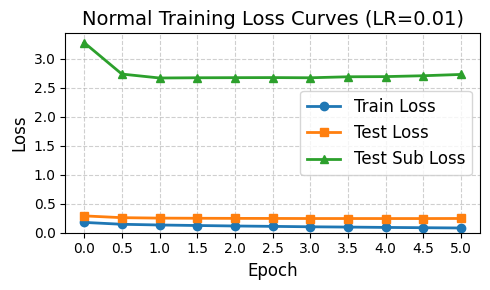

{'train_loss': array([0.17784368, 0.14564713, 0.13315542, 0.12435028, 0.11596363,
       0.10942633, 0.10221716, 0.09730095, 0.09126985, 0.08637098,
       0.08168331]), 'test_loss': array([0.29008911, 0.25940482, 0.25165907, 0.2491111 , 0.24715224,
       0.24606349, 0.24463382, 0.24449022, 0.24421242, 0.24419219,
       0.2453348 ]), 'test_sub_loss': array([3.27531528, 2.733303  , 2.66565902, 2.66952932, 2.67117491,
       2.67267196, 2.6694521 , 2.68653421, 2.68946128, 2.70454531,
       2.72687962])}


In [31]:
plot_training_losses(results_dict, title="Normal Training Loss Curves (LR=0.01)")
print(results_dict)

#### plot mixed training

In [12]:
def make_cont_train_mixed_fn(
    model,  # 👈 直接传入已复制的模型
    original_indices: np.ndarray,
    train_dataset,
    lr: float = 0.05,
    total_samples: int = 5*len(train_ds),
    random_ratio: float = 0.0,
    seed: int = 42
):
    
    set_seed(seed)
    model = copy_model(model)

    n_orig = len(original_indices)
    n_random = int(total_samples * random_ratio)
    n_repeat_orig = total_samples - n_random

    repeated_orig_indices = np.tile(original_indices, (n_repeat_orig // n_orig + 1))[:n_repeat_orig]
    random_indices = np.random.choice(np.arange(len(train_dataset)), size=n_random, replace=True)
    combined_indices = np.concatenate([repeated_orig_indices, random_indices])

    mixed_train_subds = Subset(train_dataset, combined_indices)

    return make_cont_train_curve_fn(
        model=model,  # 👈 模型在这里绑定
        train_sub_ds=mixed_train_subds,
        total_samples=total_samples,
        lr=lr,
    )

##### 找rand ratio

In [49]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

random_ratios = [0.0, 0.5, 0.8, 0.9]

multi_cls30_mixed_train_fn_list = \
	[make_cont_train_mixed_fn(model100, original_indices=train_subds.indices, 
						  	 train_dataset=train_ds,lr=0.05, random_ratio=rand_ratio) 
		for rand_ratio in random_ratios ]

# 2. 分析多次运行
cls30_results_dict_list = \
	[analyze_multi_stage_runs(target_func=multi_cls30_mixed_train_fn, repeat_num=2,) 
  					for multi_cls30_mixed_train_fn in multi_cls30_mixed_train_fn_list ]

0
25088 {'train_loss': [0.17784368547439575, 0.1466845617465973], 'test_loss': [0.29008910851478575, 0.336983113193512], 'test_sub_loss': [3.275315284729004, 2.6155948638916016]}
50176 {'train_loss': [0.17784368547439575, 0.1466845617465973, 0.057925253460168837], 'test_loss': [0.29008910851478575, 0.336983113193512, 0.35243659081459044], 'test_sub_loss': [3.275315284729004, 2.6155948638916016, 2.6536381244659424]}
75264 {'train_loss': [0.17784368547439575, 0.1466845617465973, 0.057925253460168837, 0.02435289086484909], 'test_loss': [0.29008910851478575, 0.336983113193512, 0.35243659081459044, 0.3540900237560272], 'test_sub_loss': [3.275315284729004, 2.6155948638916016, 2.6536381244659424, 2.910794973373413]}
100352 {'train_loss': [0.17784368547439575, 0.1466845617465973, 0.057925253460168837, 0.02435289086484909, 0.012935646568775177], 'test_loss': [0.29008910851478575, 0.336983113193512, 0.35243659081459044, 0.3540900237560272, 0.38373733534812926], 'test_sub_loss': [3.27531528472900

Running repeats:   0%|          | 0/1 [00:00<?, ?it/s]

0
25088 {'train_loss': [0.17784368330478667, 0.1493572148666382], 'test_loss': [0.29008910851478575, 0.3442905686855316], 'test_sub_loss': [3.275315284729004, 2.5621330738067627]}
50176 {'train_loss': [0.17784368330478667, 0.1493572148666382, 0.06687649857997895], 'test_loss': [0.29008910851478575, 0.3442905686855316, 0.36091734132766723], 'test_sub_loss': [3.275315284729004, 2.5621330738067627, 2.6546430587768555]}
75264 {'train_loss': [0.17784368330478667, 0.1493572148666382, 0.06687649857997895, 0.025829795189857483], 'test_loss': [0.29008910851478575, 0.3442905686855316, 0.36091734132766723, 0.36363618249893187], 'test_sub_loss': [3.275315284729004, 2.5621330738067627, 2.6546430587768555, 2.896782636642456]}
100352 {'train_loss': [0.17784368330478667, 0.1493572148666382, 0.06687649857997895, 0.025829795189857483, 0.011895118858516216], 'test_loss': [0.29008910851478575, 0.3442905686855316, 0.36091734132766723, 0.36363618249893187, 0.37100584778785706], 'test_sub_loss': [3.275315284

Running repeats: 100%|██████████| 1/1 [13:28<00:00, 808.47s/it]

250000 {'train_loss': [0.17784368330478667, 0.1493572148666382, 0.06687649857997895, 0.025829795189857483, 0.011895118858516216, 0.007835617247998715, 0.006094789886683226, 0.004941827212721109, 0.004131359174847603, 0.003723663010895252, 0.0033956782144457104], 'test_loss': [0.29008910851478575, 0.3442905686855316, 0.36091734132766723, 0.36363618249893187, 0.37100584778785706, 0.37315040655136106, 0.38409345383644106, 0.39368382258415224, 0.39276785945892334, 0.39698320279121396, 0.39900824193954465], 'test_sub_loss': [3.275315284729004, 2.5621330738067627, 2.6546430587768555, 2.896782636642456, 3.0446865558624268, 3.0893139839172363, 3.109017848968506, 3.1461234092712402, 3.173218250274658, 3.185093879699707, 3.211982488632202]}


...

0
25088 {'train_loss': [0.17784368547439575, 0.15602378115940094], 'test_loss': [0.29008910851478575, 0.28350051078796384], 'test_sub_loss': [3.275315284729004, 2.622631311416626]}
50176 {'train_loss': [0.17784368547439575, 0.15602378115940094, 0.1294760071940422], 'test_loss': [0.29008910851478575, 0.28350051078796384, 0.2852667184352875], 'test_sub_loss': [3.275315284729004, 2.622631311416626, 2.649313449859619]}
75264 {'train_loss': [0.17784368547439575, 0.15602378115940094, 0.1294760071940422, 0.09308847829914094], 'test_loss': [0.29008910851478575, 0.28350051078796384, 0.2852667184352875, 0.26953107056617737], 'test_sub_loss': [3.275315284729004, 2.622631311416626, 2.649313449859619, 2.701897144317627]}
100352 {'train_loss': [0.17784368547439575, 0.15602378115940094, 0.1294760071940422, 0.09308847829914094, 0.08317166966152191], 'test_loss': [0.29008910851478575, 0.28350051078796384, 0.2852667184352875, 0.26953107056617737, 0.2731819882154465], 'test_sub_loss': [3.275315284729004,

Running repeats:   0%|          | 0/1 [00:00<?, ?it/s]

0
25088 {'train_loss': [0.17784368330478667, 0.14801332925510408], 'test_loss': [0.29008910851478575, 0.2670853515625], 'test_sub_loss': [3.275315284729004, 2.5915818214416504]}
50176 {'train_loss': [0.17784368330478667, 0.14801332925510408, 0.11804205339813233], 'test_loss': [0.29008910851478575, 0.2670853515625, 0.26949266290664675], 'test_sub_loss': [3.275315284729004, 2.5915818214416504, 2.679567813873291]}
75264 {'train_loss': [0.17784368330478667, 0.14801332925510408, 0.11804205339813233, 0.11128875854349136], 'test_loss': [0.29008910851478575, 0.2670853515625, 0.26949266290664675, 0.28109575300216677], 'test_sub_loss': [3.275315284729004, 2.5915818214416504, 2.679567813873291, 2.7361464500427246]}
100352 {'train_loss': [0.17784368330478667, 0.14801332925510408, 0.11804205339813233, 0.11128875854349136, 0.08346863263559341], 'test_loss': [0.29008910851478575, 0.2670853515625, 0.26949266290664675, 0.28109575300216677, 0.2782585271835327], 'test_sub_loss': [3.275315284729004, 2.591

Running repeats: 100%|██████████| 1/1 [13:19<00:00, 799.27s/it]

250000 {'train_loss': [0.17784368330478667, 0.14801332925510408, 0.11804205339813233, 0.11128875854349136, 0.08346863263559341, 0.06951319223499298, 0.05764466813468933, 0.0659980989999771, 0.04376467997169495, 0.03893787410521507, 0.03055681682908535], 'test_loss': [0.29008910851478575, 0.2670853515625, 0.26949266290664675, 0.28109575300216677, 0.2782585271835327, 0.27187558617591856, 0.27891243200302124, 0.3176679431438446, 0.2946985822200775, 0.2972243812084198, 0.3075075912952423], 'test_sub_loss': [3.275315284729004, 2.5915818214416504, 2.679567813873291, 2.7361464500427246, 2.7576324939727783, 2.8138160705566406, 2.956425189971924, 3.0601608753204346, 3.0056076049804688, 2.9261081218719482, 3.1612069606781006]}


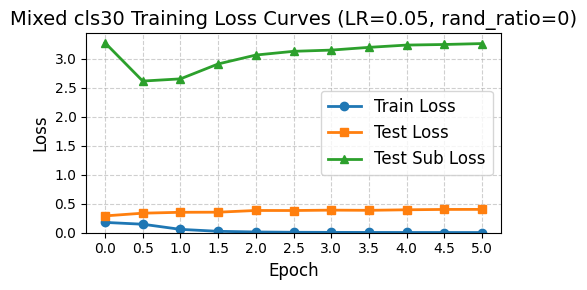

In [33]:
cls30_results_dict = {'train_loss': [0.17784368547439575, 0.1466845617465973, 0.057925253460168837, 0.02435289086484909, 0.012935646568775177, 0.0077286092755794525, 0.006088688850700855, 0.004977623375058174, 0.004165996117696166, 0.003802251220986247, 0.0034048756182044745], 
 'test_loss': [0.29008910851478575, 0.336983113193512, 0.35243659081459044, 0.3540900237560272, 0.38373733534812926, 0.3830185806751251, 0.3895860164642334, 0.3864222560405731, 0.39563698930740354, 0.40173564081192015, 0.4023042820453644], 
 'test_sub_loss': [3.275315284729004, 2.6155948638916016, 2.6536381244659424, 2.910794973373413, 3.0644798278808594, 3.1287002563476562, 3.1496968269348145, 3.197073459625244, 3.2364957332611084, 3.2465741634368896, 3.262263536453247]}
plot_training_losses(cls30_results_dict, title="Mixed cls30 Training Loss Curves (LR=0.05, rand_ratio=0)")

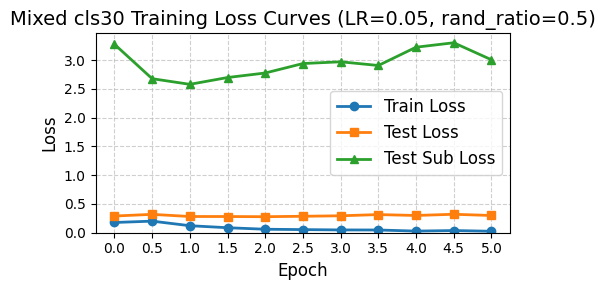

In [ ]:
cls30_results_dict = {'train_loss': [0.17784368547439575, 0.20129895320129396, 0.12191601235961914, 0.08680833171701431, 0.06066989449596405, 0.05418569926023483, 0.04841889655184746, 0.04741781551873684, 0.028094663883209227, 0.03771534678554535, 0.02533280685776472], 
					  'test_loss': [0.29008910851478575, 0.3192882302761078, 0.28189442210197446, 0.28136772937774657, 0.2784577088832855, 0.28576665840148924, 0.2942238489151001, 0.31522144746780395, 0.29981594247817994, 0.3207595480442047, 0.2993498367071152], 
					  'test_sub_loss': [3.275315284729004, 2.6766574382781982, 2.578464984893799, 2.6968483924865723, 2.7754101753234863, 2.939864158630371, 2.970102071762085, 2.9059066772460938, 3.2237281799316406, 3.3009564876556396, 3.0053980350494385]}
plot_training_losses(cls30_results_dict, title="Mixed cls30 Training Loss Curves (LR=0.05, rand_ratio=0.5)")

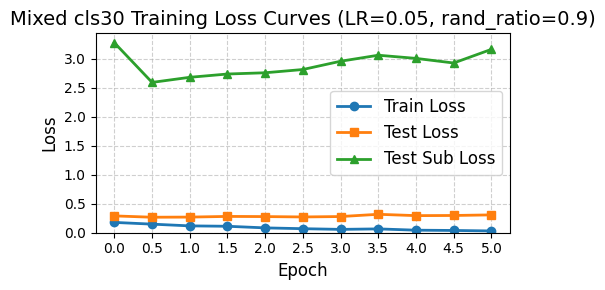

In [16]:
cls30_results_dict = {'train_loss': [0.17784368330478667, 0.14801332925510408, 0.11804205339813233, 0.11128875854349136, 0.08346863263559341, 0.06951319223499298, 0.05764466813468933, 0.0659980989999771, 0.04376467997169495, 0.03893787410521507, 0.03055681682908535], 
						'test_loss': [0.29008910851478575, 0.2670853515625, 0.26949266290664675, 0.28109575300216677, 0.2782585271835327, 0.27187558617591856, 0.27891243200302124, 0.3176679431438446, 0.2946985822200775, 0.2972243812084198, 0.3075075912952423], 
						'test_sub_loss': [3.275315284729004, 2.5915818214416504, 2.679567813873291, 2.7361464500427246, 2.7576324939727783, 2.8138160705566406, 2.956425189971924, 3.0601608753204346, 3.0056076049804688, 2.9261081218719482, 3.1612069606781006]}

plot_training_losses(cls30_results_dict, title="Mixed cls30 Training Loss Curves (LR=0.05, rand_ratio=0.9)")

##### train

In [44]:
train_indices_arrs = np.load('train_indices_arrs.npy')
train_sub_indices = np.reshape(train_indices_arrs, (-1,))
train_subds = Subset(train_ds, train_sub_indices)

multi_cls30_mixed_train_fn = make_cont_train_mixed_fn(model100, original_indices=train_subds.indices, 
						  	 train_dataset=train_ds,lr=0.05, random_ratio=0.8)

# 2. 分析多次运行
cls30_results_dict = analyze_multi_stage_runs(target_func=multi_cls30_mixed_train_fn, repeat_num=10,)

0
25088 {'train_loss': [0.17784368547439575, 0.16232927561092378], 'test_loss': [0.29008910851478575, 0.27733453068733216], 'test_sub_loss': [3.275315284729004, 2.592277765274048]}
50176 {'train_loss': [0.17784368547439575, 0.16232927561092378, 0.13332284657812118], 'test_loss': [0.29008910851478575, 0.27733453068733216, 0.2808061906337738], 'test_sub_loss': [3.275315284729004, 2.592277765274048, 2.692007541656494]}
75264 {'train_loss': [0.17784368547439575, 0.16232927561092378, 0.13332284657812118, 0.10761468242835999], 'test_loss': [0.29008910851478575, 0.27733453068733216, 0.2808061906337738, 0.2824052234649658], 'test_sub_loss': [3.275315284729004, 2.592277765274048, 2.692007541656494, 2.765653371810913]}
100352 {'train_loss': [0.17784368547439575, 0.16232927561092378, 0.13332284657812118, 0.10761468242835999, 0.07967702569389343], 'test_loss': [0.29008910851478575, 0.27733453068733216, 0.2808061906337738, 0.2824052234649658, 0.2707266464233398], 'test_sub_loss': [3.275315284729004

Running repeats:   0%|          | 0/9 [00:00<?, ?it/s]

0
25088 {'train_loss': [0.17784368330478667, 0.1623591890707016], 'test_loss': [0.29008910851478575, 0.2872849610805511], 'test_sub_loss': [3.275315284729004, 2.703366756439209]}
50176 {'train_loss': [0.17784368330478667, 0.1623591890707016, 0.12691927518081664], 'test_loss': [0.29008910851478575, 0.2872849610805511, 0.27669564146995546], 'test_sub_loss': [3.275315284729004, 2.703366756439209, 2.527776002883911]}
75264 {'train_loss': [0.17784368330478667, 0.1623591890707016, 0.12691927518081664, 0.10528795940303802], 'test_loss': [0.29008910851478575, 0.2872849610805511, 0.27669564146995546, 0.2823072922229767], 'test_sub_loss': [3.275315284729004, 2.703366756439209, 2.527776002883911, 2.749598741531372]}
100352 {'train_loss': [0.17784368330478667, 0.1623591890707016, 0.12691927518081664, 0.10528795940303802, 0.07902974713850021], 'test_loss': [0.29008910851478575, 0.2872849610805511, 0.27669564146995546, 0.2823072922229767, 0.276964918756485], 'test_sub_loss': [3.275315284729004, 2.70

Running repeats:  11%|█         | 1/9 [13:31<1:48:10, 811.35s/it]

250000 {'train_loss': [0.17784368330478667, 0.1623591890707016, 0.12691927518081664, 0.10528795940303802, 0.07902974713850021, 0.0752473249578476, 0.05861004710435867, 0.049274938401222226, 0.04246167142701149, 0.03655536252689361, 0.02622228938806057], 'test_loss': [0.29008910851478575, 0.2872849610805511, 0.27669564146995546, 0.2823072922229767, 0.276964918756485, 0.28575739278793333, 0.2912017053604126, 0.29390134105682375, 0.29893816614151003, 0.3090290006637573, 0.29913418617248533], 'test_sub_loss': [3.275315284729004, 2.703366756439209, 2.527776002883911, 2.749598741531372, 2.844971179962158, 2.7661755084991455, 2.9849674701690674, 2.9524264335632324, 3.048814296722412, 3.190701961517334, 3.1173763275146484]}
0
25088 {'train_loss': [0.17784368434429168, 0.17432731114578248], 'test_loss': [0.29008910851478575, 0.2944453440666199], 'test_sub_loss': [3.275315284729004, 2.8125250339508057]}
50176 {'train_loss': [0.17784368434429168, 0.17432731114578248, 0.1289472640852928], 'test_lo

...

250000 {'train_loss': [0.1778436859369278, 0.16619245772075653, 0.12009427941131592, 0.0993764539179802, 0.09516623697185517, 0.07391467538881302, 0.062375953578233716, 0.049135305965423585, 0.0383186163598299, 0.031030292127251623, 0.028239601524591446], 'test_loss': [0.29008910851478575, 0.28604267661571503, 0.26063768656253816, 0.26593903415203096, 0.2942511733055115, 0.29226074233055116, 0.29974529271125794, 0.29921793694496157, 0.2929698111057282, 0.3011723854780197, 0.3017079529762268], 'test_sub_loss': [3.275315284729004, 2.6480157375335693, 2.5577313899993896, 2.531656503677368, 2.902087926864624, 2.9414265155792236, 2.906648874282837, 2.918531894683838, 3.0229456424713135, 3.107757806777954, 3.1097052097320557]}
0
25088 {'train_loss': [0.1778436827468872, 0.178793565533638], 'test_loss': [0.29008910851478575, 0.2920399019241333], 'test_sub_loss': [3.275315284729004, 2.653240203857422]}
50176 {'train_loss': [0.1778436827468872, 0.178793565533638, 0.1310783119878769], 'test_loss

Running repeats:  89%|████████▉ | 8/9 [1:49:00<13:37, 817.89s/it]

250000 {'train_loss': [0.1778436827468872, 0.178793565533638, 0.1310783119878769, 0.11526179760313034, 0.08550997215723992, 0.060963057407617566, 0.050877191634655, 0.04274443846440315, 0.035786342160224915, 0.028114095845818518, 0.032004790139555934], 'test_loss': [0.29008910851478575, 0.2920399019241333, 0.2814698159694672, 0.2824224956512451, 0.2839404242992401, 0.2665819753885269, 0.271364150428772, 0.27488271787166596, 0.28734173545837405, 0.2880102903842926, 0.31362330498695373], 'test_sub_loss': [3.275315284729004, 2.653240203857422, 2.5487442016601562, 2.536989450454712, 2.7521793842315674, 2.7248575687408447, 2.912285089492798, 2.919325113296509, 3.0077950954437256, 3.090245008468628, 3.2207729816436768]}
0
25088 {'train_loss': [0.17784367995262146, 0.16404279222011567], 'test_loss': [0.29008910851478575, 0.27850659022331237], 'test_sub_loss': [3.275315284729004, 2.4811313152313232]}
50176 {'train_loss': [0.17784367995262146, 0.16404279222011567, 0.12299350466299057], 'test_lo

Running repeats: 100%|██████████| 9/9 [2:02:26<00:00, 816.27s/it]

250000 {'train_loss': [0.17784367995262146, 0.16404279222011567, 0.12299350466299057, 0.10418889592075348, 0.08213348424005508, 0.07471396866083145, 0.06272581132459641, 0.048402032037377356, 0.03843558535289764, 0.04283632968723774, 0.028003168474912642], 'test_loss': [0.29008910851478575, 0.27850659022331237, 0.2721657784461975, 0.2784179981231689, 0.2863760453701019, 0.29085477890968325, 0.29323116626739504, 0.289595015668869, 0.2924947124004364, 0.3179823351383209, 0.3024302990913391], 'test_sub_loss': [3.275315284729004, 2.4811313152313232, 2.6389265060424805, 2.642793655395508, 2.925820827484131, 2.773979663848877, 3.051187753677368, 2.824406862258911, 3.00779390335083, 3.2495455741882324, 3.2147486209869385]}


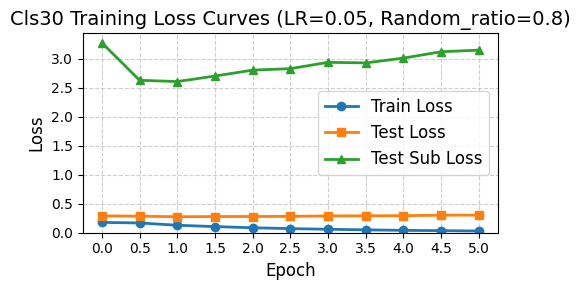

{'train_loss': array([0.17784368, 0.1684344 , 0.1290183 , 0.10575645, 0.08541117,
       0.07089877, 0.05984342, 0.04952571, 0.04072725, 0.03582791,
       0.02931708]), 'test_loss': array([0.29008911, 0.28471081, 0.2758248 , 0.2792608 , 0.27952979,
       0.28192633, 0.28942387, 0.29184299, 0.29403084, 0.30280663,
       0.3035446 ]), 'test_sub_loss': array([3.27531528, 2.62781963, 2.60650897, 2.70171258, 2.80302083,
       2.82857771, 2.93812983, 2.9277477 , 3.0107574 , 3.12028484,
       3.14759998])}


In [45]:
plot_training_losses(cls30_results_dict, title="Cls30 Training Loss Curves (LR=0.05, Random_ratio=0.8)")
print(cls30_results_dict)

#### plot filtered training

In [ ]:
# num_poisson = 20

not_train_indices = np.load("not_to_train_indices.npy")

bad_indices = set(not_train_indices)  # 转成集合加速查询
all_indices = [i for i in range(len(train_ds)) if i not in bad_indices]

filtered_ds = Subset(train_ds, all_indices)

not_to_train_fn = make_cont_train_curve_fn(model100, filtered_ds, lr=0.01)
filtered_run_results_dict = analyze_multi_stage_runs(
	target_func=not_to_train_fn,
	repeat_num=10
)

0
25088 {'train_loss': [0.17879311300928222, 0.1464478122573241], 'test_loss': [0.29008910851478575, 0.25939950580596927], 'test_sub_loss': [3.275315284729004, 2.72263240814209]}
50152 {'train_loss': [0.17879311300928222, 0.1464478122573241, 0.13357999917482966], 'test_loss': [0.29008910851478575, 0.25939950580596927, 0.25197198514938357], 'test_sub_loss': [3.275315284729004, 2.72263240814209, 2.6821935176849365]}
75240 {'train_loss': [0.17879311300928222, 0.1464478122573241, 0.13357999917482966, 0.1241781012952856], 'test_loss': [0.29008910851478575, 0.25939950580596927, 0.25197198514938357, 0.2500626960515976], 'test_sub_loss': [3.275315284729004, 2.72263240814209, 2.6821935176849365, 2.6841306686401367]}
100304 {'train_loss': [0.17879311300928222, 0.1464478122573241, 0.13357999917482966, 0.1241781012952856, 0.11628520435906532], 'test_loss': [0.29008910851478575, 0.25939950580596927, 0.25197198514938357, 0.2500626960515976, 0.24650593700408935], 'test_sub_loss': [3.275315284729004, 

Running repeats: 0it [00:00, ?it/s]


In [24]:
# num_poisson = 20

not_train_indices = np.load("not_to_train_indices.npy")

bad_indices = set(not_train_indices)  # 转成集合加速查询
all_indices = [i for i in range(len(train_ds)) if i not in bad_indices]

filtered_ds = Subset(train_ds, all_indices)

not_to_train_fn = make_cont_train_curve_fn(model100, filtered_ds, lr=0.01)
filtered_run_results_dict = analyze_multi_stage_runs(
	target_func=not_to_train_fn,
	repeat_num=10
)

0
25088 {'train_loss': [0.17784368547439575, 0.1464478122573241], 'test_loss': [0.29008910851478575, 0.25939950580596927], 'test_sub_loss': [3.275315284729004, 2.72263240814209]}
50152 {'train_loss': [0.17784368547439575, 0.1464478122573241, 0.13357999917482966], 'test_loss': [0.29008910851478575, 0.25939950580596927, 0.25197198514938357], 'test_sub_loss': [3.275315284729004, 2.72263240814209, 2.6821935176849365]}
75240 {'train_loss': [0.17784368547439575, 0.1464478122573241, 0.13357999917482966, 0.1241781012952856], 'test_loss': [0.29008910851478575, 0.25939950580596927, 0.25197198514938357, 0.2500626960515976], 'test_sub_loss': [3.275315284729004, 2.72263240814209, 2.6821935176849365, 2.6841306686401367]}
100304 {'train_loss': [0.17784368547439575, 0.1464478122573241, 0.13357999917482966, 0.1241781012952856, 0.11628520435906532], 'test_loss': [0.29008910851478575, 0.25939950580596927, 0.25197198514938357, 0.2500626960515976, 0.24650593700408935], 'test_sub_loss': [3.275315284729004, 

Running repeats:   0%|          | 0/9 [00:00<?, ?it/s]

0
25088 {'train_loss': [0.17784368330478667, 0.147578486372731], 'test_loss': [0.29008910851478575, 0.26143674387931826], 'test_sub_loss': [3.275315284729004, 2.7356698513031006]}
50152 {'train_loss': [0.17784368330478667, 0.147578486372731, 0.13467689258354887], 'test_loss': [0.29008910851478575, 0.26143674387931826, 0.25309137930870057], 'test_sub_loss': [3.275315284729004, 2.7356698513031006, 2.6514053344726562]}
75240 {'train_loss': [0.17784368330478667, 0.147578486372731, 0.13467689258354887, 0.12560083924235113], 'test_loss': [0.29008910851478575, 0.26143674387931826, 0.25309137930870057, 0.24911732623577118], 'test_sub_loss': [3.275315284729004, 2.7356698513031006, 2.6514053344726562, 2.644468307495117]}
100304 {'train_loss': [0.17784368330478667, 0.147578486372731, 0.13467689258354887, 0.12560083924235113, 0.11670880072016951], 'test_loss': [0.29008910851478575, 0.26143674387931826, 0.25309137930870057, 0.24911732623577118, 0.2459148461818695], 'test_sub_loss': [3.2753152847290

Running repeats:  11%|█         | 1/9 [04:22<35:03, 262.94s/it]

250248 {'train_loss': [0.17784368330478667, 0.147578486372731, 0.13467689258354887, 0.12560083924235113, 0.11670880072016951, 0.11022467903318567, 0.10340289480497912, 0.0980069644935279, 0.0915335646591102, 0.08680368750254826, 0.08180009948928735], 'test_loss': [0.29008910851478575, 0.26143674387931826, 0.25309137930870057, 0.24911732623577118, 0.2459148461818695, 0.24773745200634004, 0.2447906249523163, 0.24496155705451966, 0.2444570796251297, 0.24413878116607665, 0.24468916835784912], 'test_sub_loss': [3.275315284729004, 2.7356698513031006, 2.6514053344726562, 2.644468307495117, 2.641356945037842, 2.70171856880188, 2.6499571800231934, 2.7047011852264404, 2.7035794258117676, 2.710740804672241, 2.739645481109619]}
0
25088 {'train_loss': [0.17784368434429168, 0.14637186620429482], 'test_loss': [0.29008910851478575, 0.2586644157409668], 'test_sub_loss': [3.275315284729004, 2.726783037185669]}
50152 {'train_loss': [0.17784368434429168, 0.14637186620429482, 0.13310898359891968], 'test_lo

...

250248 {'train_loss': [0.1778436859369278, 0.14629832914911098, 0.13395866972606668, 0.12470539821721584, 0.11635288486405787, 0.1093785670426082, 0.10346894818842171, 0.0981899090765658, 0.09165363661782766, 0.08737610053814389, 0.08191830769337348], 'test_loss': [0.29008910851478575, 0.2588481019973755, 0.25121051430702207, 0.2487700593471527, 0.2456388619661331, 0.2463194662094116, 0.2431909674167633, 0.24444234838485718, 0.2449047921180725, 0.2445836319208145, 0.24547495341300965], 'test_sub_loss': [3.275315284729004, 2.752288341522217, 2.653764486312866, 2.661638021469116, 2.6405255794525146, 2.690538167953491, 2.661252021789551, 2.655203342437744, 2.7001962661743164, 2.714535713195801, 2.738264322280884]}
0
25088 {'train_loss': [0.1778436827468872, 0.14596402968589958], 'test_loss': [0.29008910851478575, 0.2593710210323334], 'test_sub_loss': [3.275315284729004, 2.7591817378997803]}
50152 {'train_loss': [0.1778436827468872, 0.14596402968589958, 0.133922750724361], 'test_loss': [0.

Running repeats:  89%|████████▉ | 8/9 [35:13<04:24, 264.71s/it]

250248 {'train_loss': [0.1778436827468872, 0.14596402968589958, 0.133922750724361, 0.1257977680632609, 0.11755112052972426, 0.10991998680122046, 0.10281061194747038, 0.09770995875960103, 0.09140489261108094, 0.08658019643123836, 0.08179630428000288], 'test_loss': [0.29008910851478575, 0.2593710210323334, 0.25201008739471437, 0.24847413160800935, 0.24861062405109405, 0.24659860084056853, 0.2445102791786194, 0.24560793602466582, 0.24368262379169464, 0.24524270610809326, 0.24406477825641631], 'test_sub_loss': [3.275315284729004, 2.7591817378997803, 2.6714470386505127, 2.638697624206543, 2.6593101024627686, 2.6658384799957275, 2.698608875274658, 2.6723246574401855, 2.718435525894165, 2.7104451656341553, 2.7209935188293457]}
0
25088 {'train_loss': [0.17784367995262146, 0.1460547285777345], 'test_loss': [0.29008910851478575, 0.2588005003929138], 'test_sub_loss': [3.275315284729004, 2.701406955718994]}
50152 {'train_loss': [0.17784367995262146, 0.1460547285777345, 0.13555622772763182], 'test_

Running repeats: 100%|██████████| 9/9 [39:43<00:00, 264.79s/it]

250248 {'train_loss': [0.17784367995262146, 0.1460547285777345, 0.13555622772763182, 0.12484174229799021, 0.11628833963662553, 0.11063000756127521, 0.10317326723616706, 0.097347511560037, 0.09101564325842523, 0.08661973698786629, 0.08227113953624206], 'test_loss': [0.29008910851478575, 0.2588005003929138, 0.25508493137359617, 0.24795369946956636, 0.24641768021583557, 0.24636135368347167, 0.24457113807201386, 0.24429570903778075, 0.24436561069488524, 0.24463686056137085, 0.24464472920894623], 'test_sub_loss': [3.275315284729004, 2.701406955718994, 2.7231225967407227, 2.650402307510376, 2.674584150314331, 2.6614434719085693, 2.6740901470184326, 2.6928746700286865, 2.7289538383483887, 2.7050392627716064, 2.7369649410247803]}


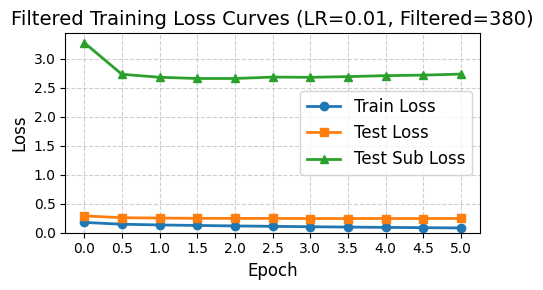

{'train_loss': array([0.17784368, 0.14645499, 0.13394355, 0.12505751, 0.11682878,
       0.11009552, 0.10305401, 0.09748374, 0.09159947, 0.08698378,
       0.08213324]), 'test_loss': array([0.29008911, 0.25903517, 0.25215176, 0.24875018, 0.24669082,
       0.24666692, 0.24474804, 0.24478842, 0.24465   , 0.24485708,
       0.2450248 ]), 'test_sub_loss': array([3.27531528, 2.72935288, 2.67808387, 2.65702505, 2.65699303,
       2.68121233, 2.67747133, 2.68940952, 2.70633609, 2.7149982 ,
       2.73276954])}


In [25]:
plot_training_losses(filtered_run_results_dict, title="Filtered Training Loss Curves (LR=0.01, Filtered=380)")
print(filtered_run_results_dict)

In [26]:
not_to_train_fn = make_cont_train_curve_fn(model100, filtered_ds, 
										   lr=0.05, )
filtered_run_results_dict = analyze_multi_stage_runs(
	target_func=not_to_train_fn,
	repeat_num=10
)

0
25088 {'train_loss': [0.17784368547439575, 0.15045705641785714], 'test_loss': [0.29008910851478575, 0.28075825548171995], 'test_sub_loss': [3.275315284729004, 2.680588722229004]}
50152 {'train_loss': [0.17784368547439575, 0.15045705641785714, 0.12404069268444101], 'test_loss': [0.29008910851478575, 0.28075825548171995, 0.26954937438964843], 'test_sub_loss': [3.275315284729004, 2.680588722229004, 2.614635467529297]}
75240 {'train_loss': [0.17784368547439575, 0.15045705641785714, 0.12404069268444101, 0.09755554874633994], 'test_loss': [0.29008910851478575, 0.28075825548171995, 0.26954937438964843, 0.26405171308517456], 'test_sub_loss': [3.275315284729004, 2.680588722229004, 2.614635467529297, 2.5678200721740723]}
100304 {'train_loss': [0.17784368547439575, 0.15045705641785714, 0.12404069268444101, 0.09755554874633994, 0.08342224589693845], 'test_loss': [0.29008910851478575, 0.28075825548171995, 0.26954937438964843, 0.26405171308517456, 0.265275413608551], 'test_sub_loss': [3.2753152847

Running repeats:   0%|          | 0/9 [00:00<?, ?it/s]

0
25088 {'train_loss': [0.17784368330478667, 0.14872327410915415], 'test_loss': [0.29008910851478575, 0.27538844394683837], 'test_sub_loss': [3.275315284729004, 2.619687795639038]}
50152 {'train_loss': [0.17784368330478667, 0.14872327410915415, 0.1259810407684274], 'test_loss': [0.29008910851478575, 0.27538844394683837, 0.270242622423172], 'test_sub_loss': [3.275315284729004, 2.619687795639038, 2.4387004375457764]}
75240 {'train_loss': [0.17784368330478667, 0.14872327410915415, 0.1259810407684274, 0.08950120087571917], 'test_loss': [0.29008910851478575, 0.27538844394683837, 0.270242622423172, 0.2506540340900421], 'test_sub_loss': [3.275315284729004, 2.619687795639038, 2.4387004375457764, 2.5611164569854736]}
100304 {'train_loss': [0.17784368330478667, 0.14872327410915415, 0.1259810407684274, 0.08950120087571917, 0.08270685179256605], 'test_loss': [0.29008910851478575, 0.27538844394683837, 0.270242622423172, 0.2506540340900421, 0.267855198097229], 'test_sub_loss': [3.275315284729004, 2.

Running repeats:  11%|█         | 1/9 [04:25<35:20, 265.05s/it]

250248 {'train_loss': [0.17784368330478667, 0.14872327410915415, 0.1259810407684274, 0.08950120087571917, 0.08270685179256605, 0.06754892872500862, 0.057868462533214995, 0.047409399600037636, 0.03973663964223996, 0.03013384115254082, 0.03014989617062278], 'test_loss': [0.29008910851478575, 0.27538844394683837, 0.270242622423172, 0.2506540340900421, 0.267855198097229, 0.2713751542329788, 0.2739144127845764, 0.2743854388237, 0.2874834875583649, 0.28513795585632323, 0.2907657199859619], 'test_sub_loss': [3.275315284729004, 2.619687795639038, 2.4387004375457764, 2.5611164569854736, 2.706190347671509, 2.8107752799987793, 2.757803440093994, 2.8317654132843018, 3.029507875442505, 2.953024387359619, 2.963312864303589]}
0
25088 {'train_loss': [0.17784368434429168, 0.14879398952079914], 'test_loss': [0.29008910851478575, 0.2725628060340881], 'test_sub_loss': [3.275315284729004, 2.5841572284698486]}
50152 {'train_loss': [0.17784368434429168, 0.14879398952079914, 0.12466091309388158], 'test_loss':

...

250248 {'train_loss': [0.1778436859369278, 0.14850595130928096, 0.12406447725873336, 0.10243465637339401, 0.09096728890029583, 0.06305538766404298, 0.06193567737636789, 0.042928014650016326, 0.043151022661942616, 0.025959867889198154, 0.035125518545184184], 'test_loss': [0.29008910851478575, 0.2768670641899109, 0.27164200463294985, 0.2699990198135376, 0.2781185224056244, 0.26303722310066224, 0.27591967964172365, 0.27414034740924836, 0.28720509519577025, 0.27367428812980654, 0.31445228328704833], 'test_sub_loss': [3.275315284729004, 2.710042715072632, 2.5040526390075684, 2.6175696849823, 2.7090256214141846, 2.7788641452789307, 2.7214553356170654, 2.8661928176879883, 2.974574327468872, 3.0691659450531006, 3.241838216781616]}
0
25088 {'train_loss': [0.1778436827468872, 0.14627465721486943], 'test_loss': [0.29008910851478575, 0.27475106291770934], 'test_sub_loss': [3.275315284729004, 2.7018189430236816]}
50152 {'train_loss': [0.1778436827468872, 0.14627465721486943, 0.12639341193951492], '

Running repeats:  89%|████████▉ | 8/9 [35:24<04:25, 265.02s/it]

250248 {'train_loss': [0.1778436827468872, 0.14627465721486943, 0.12639341193951492, 0.0925331323018101, 0.09025172421905324, 0.06608237408936071, 0.05949487798426249, 0.04754463538503474, 0.04193270000824997, 0.025165078010917382, 0.02459339773932308], 'test_loss': [0.29008910851478575, 0.27475106291770934, 0.27214851460456846, 0.2515313350200653, 0.27901073260307313, 0.2638808771133423, 0.272479031085968, 0.2777376567840576, 0.2884467161655426, 0.27391440362930297, 0.2947641664981842], 'test_sub_loss': [3.275315284729004, 2.7018189430236816, 2.593348741531372, 2.4787681102752686, 2.6834330558776855, 2.7234363555908203, 2.8154728412628174, 2.913480520248413, 2.9131240844726562, 3.0381298065185547, 3.2126331329345703]}
0
25088 {'train_loss': [0.17784367995262146, 0.146512837617941], 'test_loss': [0.29008910851478575, 0.2748485041618347], 'test_sub_loss': [3.275315284729004, 2.634904623031616]}
50152 {'train_loss': [0.17784367995262146, 0.146512837617941, 0.11993952167793016], 'test_los

Running repeats: 100%|██████████| 9/9 [39:52<00:00, 265.87s/it]

250248 {'train_loss': [0.17784367995262146, 0.146512837617941, 0.11993952167793016, 0.1008460272784967, 0.08063009781740443, 0.07760811249855351, 0.05903815972550467, 0.046601834053910614, 0.04539645601012935, 0.027717110414379166, 0.03136110370716052], 'test_loss': [0.29008910851478575, 0.2748485041618347, 0.2647386644363403, 0.26968741540908814, 0.2559730658531189, 0.28240384254455564, 0.2776632575035095, 0.2799609674453735, 0.2950374979019165, 0.2765190810203552, 0.3054212888717651], 'test_sub_loss': [3.275315284729004, 2.634904623031616, 2.5540974140167236, 2.6676952838897705, 2.5980448722839355, 2.7666382789611816, 2.8046157360076904, 2.9150679111480713, 3.1059181690216064, 3.0041561126708984, 3.096161365509033]}


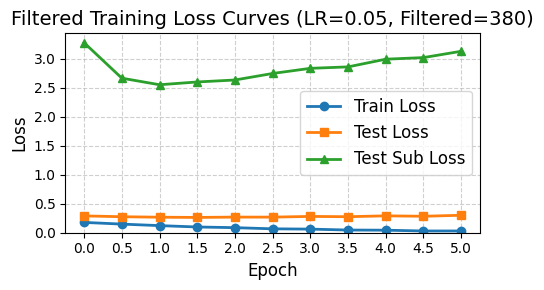

{'train_loss': array([0.17784368, 0.14869281, 0.12239539, 0.09897312, 0.08728232,
       0.06720344, 0.06233305, 0.0462064 , 0.04365081, 0.02989478,
       0.03010186]), 'test_loss': array([0.29008911, 0.27575835, 0.26747703, 0.26359358, 0.2693638 ,
       0.26881548, 0.28113648, 0.27611499, 0.2909292 , 0.28377184,
       0.30101963]), 'test_sub_loss': array([3.27531528, 2.66442411, 2.55128818, 2.59912987, 2.63303998,
       2.74566875, 2.83426602, 2.85922685, 2.99189682, 3.01929202,
       3.12828381])}


In [27]:
plot_training_losses(filtered_run_results_dict, title="Filtered Training Loss Curves (LR=0.05, Filtered=380)")
print(filtered_run_results_dict)